# Decorrelation Scales Simulations  

**Purpose**: Code for building inituition about decorrelation scales from synthetic data. Here, we will be preforming the following analysis:

1. ***Small vs. Large Scale contributions***: Testing how small and large scale variability influence the decorrelation scale. Additionally, we test an analytical equation for the decorrelation scale (assumes data has a red spectral slope $\alpha$)
2. ***Computing uncertainties***: Testing two methods for computing uncertainties of decorrelation scales, namely bootstrapping and perturbing the mean autocorrelation function. The goal here is to see how well each method estimating error in the decorrelation scale estimate 
3. ***Methods for computing the decorrelation scale***: Evaluating the difference methods for computing the decorrelation scale. These include: 
    1. **Integral scale**: Integrating the autocorrelation function from the negative-lag zero crossing to the positive-lag zero crossing.  
    2. **e-Folding scale**: Lag where rho = 1/e ≈ 0.3679
    3. **Zero-crossing scale**: Lag where rho first crosses 0
    4. **Half-width at half-maximum** Lag where rho = 0.5
    5. **Exponential fit** Fit rho ~ exp(-lag/L) to small-lag ACF
4. ***Windowing Analysis***: Compute the decorrelation scale at varying window sizes for red spectrum with different slopes.  

**Luke Colosi | lcolosi@ucsd.edu**

Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from scipy.signal import detrend
from scipy.integrate import trapezoid
from datetime import datetime, timedelta
import cmocean.cm as cmo

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
from spectra import generate_powerlaw_data, spectrum1D_frequency_nonwelch
from autocorr import compute_autocorr_optimize, compute_decor_scale_optimize,bootstrap_decorrelation_scale, segment_time_series, compute_decorrelation_scales, windowed_decorrelation_scale
from lsf import unweighted_lsf
from plotScaleAnalysis import add_corner_label

Set plotting parameters

In [2]:
fontsize = 16
PATH_figs   = ROOT + 'AirSeaCoupling/figs/paper_figures/'

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
plt.rcParams.update({
    "font.size": fontsize,                          # Fontsize
    "text.usetex": True,                           # Use LaTeX for all text
    "font.family": "serif",                         # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
})

## **Section 1**: Small vs. Large Scale contributions

Set processing parameters

In [3]:
N = 2**12             # Number of data points
alpha = [0.5,2.0]     # Spectral slope
dt = 1                # Time interval between data points (units: hours)

Generate time series with prescribed spectral slope

In [4]:
# Compute spectrum 
t1, x1, f1, psd1 = generate_powerlaw_data(N=N, alpha=alpha[0], random_state=42,dt=dt)
t2, x2, f2, psd2 = generate_powerlaw_data(N=N, alpha=alpha[1], random_state=42,dt=dt)

# Convert time to days
t1_days = t1 * (1/24)
t2_days = t2 * (1/24)

# Convert frequency to cpd
f1_cpd = f1 * 24
f2_cpd = f2 * 24

Plot the Synthetic time series and spectrum 

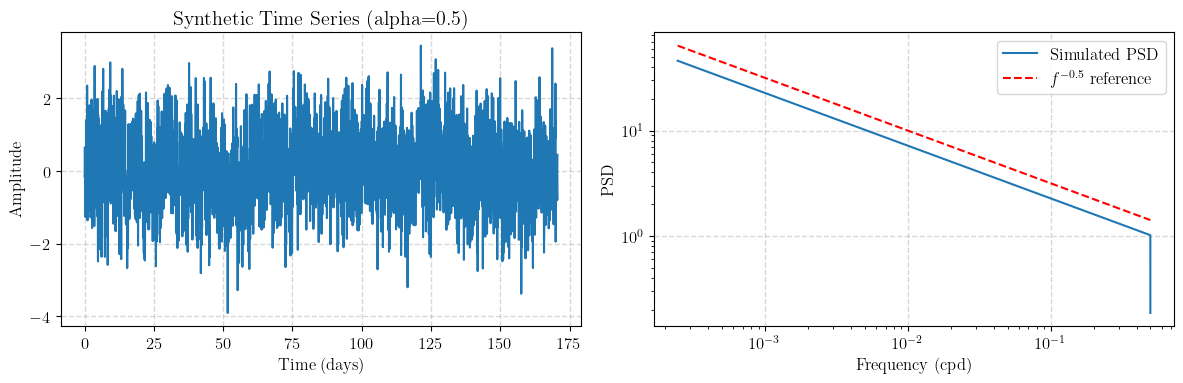

In [5]:
# Create figure
fig,axes = plt.subplots(1,2,figsize=(12,4))
ax1, ax2 = axes.flatten()

#--- Subplot 1 ---# 
ax1.plot(t1_days, x1, color='tab:blue')

# Set axis attributes
ax1.set_title('Synthetic Time Series (alpha=' + str(alpha[0]) + ')')
ax1.set_xlabel("Time (days)")
ax1.set_ylabel("Amplitude")
ax1.grid(ls='--',lw=1.0,alpha=0.5)

#--- Subplot 1 ---# 
ax2.loglog(f1[1:], psd1[1:], color='tab:blue', label="Simulated PSD")
plt.loglog(f1[1:], f1[1:]**(-alpha[0]), 'r--', label=r"$f^{-" + str(alpha[0]) + r"}$ reference")

# Set axis attributes
ax2.set_xlabel("Frequency (cpd)")
ax2.set_ylabel("PSD")
ax2.legend()
ax2.grid(ls='--',lw=1.0,alpha=0.5)

# Display figure
plt.tight_layout()
plt.show()

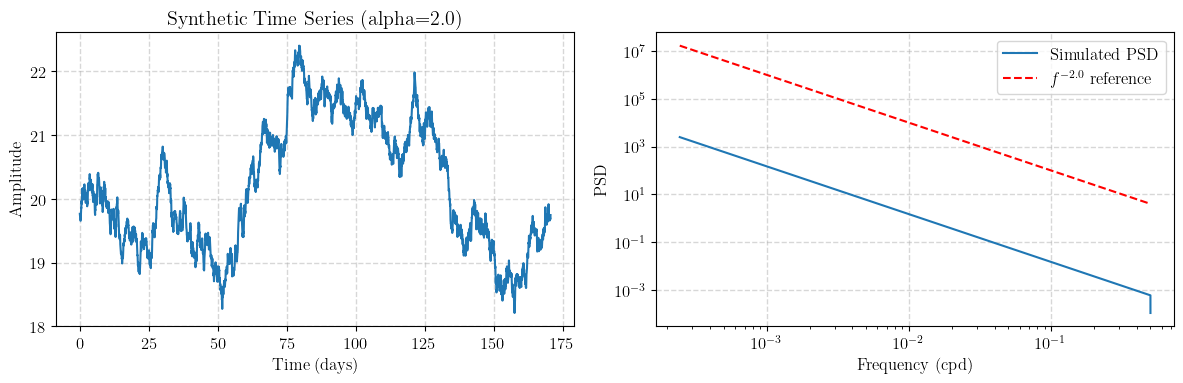

In [6]:
# Create figure
fig,axes = plt.subplots(1,2,figsize=(12,4))
ax1, ax2 = axes.flatten()

#--- Subplot 1 ---# 
ax1.plot(t2_days, x2, color='tab:blue')

# Set axis attributes
ax1.set_title('Synthetic Time Series (alpha=' + str(alpha[1]) + ')')
ax1.set_xlabel("Time (days)")
ax1.set_ylabel("Amplitude")
ax1.grid(ls='--',lw=1.0,alpha=0.5)

#--- Subplot 1 ---# 
ax2.loglog(f2[1:], psd2[1:], color='tab:blue', label="Simulated PSD")
plt.loglog(f2[1:], f2[1:]**(-alpha[1]), 'r--', label=r"$f^{-" + str(alpha[1]) + r"}$ reference")

# Set axis attributes
ax2.set_xlabel("Frequency (cpd)")
ax2.set_ylabel("PSD")
ax2.legend()
ax2.grid(ls='--',lw=1.0,alpha=0.5)

# Display figure
plt.tight_layout()
plt.show()


Compute the decorrelation scale numerically and theoretically  

In [7]:
# Detrend time series 
x1_dt = detrend(x1)
x2_dt = detrend(x2)

# Compute autocorrelation function
autocorr1, _, _, _, time_scale1, _ = compute_autocorr_optimize(x1_dt, t1, N, 'biased', 0)
autocorr2, _, _, _, time_scale2, _ = compute_autocorr_optimize(x2_dt, t2, N, 'biased', 0)

# Compute the decorrelation scale numerically
Lt1 = compute_decor_scale_optimize(autocorr1,time_scale1,dt,'unbiased',0)
Lt2 = compute_decor_scale_optimize(autocorr2,time_scale2,dt,'unbiased',0)

# Convert to days
Lt1_days = Lt1 * (1/24)
Lt2_days = Lt2 * (1/24)

# Compute the decorrelation scale theoretically 
f1_min, f1_max = f1[1], f1[-1]
f2_min, f2_max = f2[1], f2[-1]
# Lt1_theory = (1 - alpha[0]) * ((f1_min**(-alpha[0]))/(f1_max**(1-alpha[0]) - f1_min**(1-alpha[0])))
# Lt2_theory = (1 - alpha[1]) * ((f2_min**(-alpha[1]))/(f2_max**(1-alpha[1]) - f2_min**(1-alpha[1])))
Lt1_theory = (1 - alpha[0]) * ((f1_min**(-alpha[0]))/(f1_max**(1-alpha[0])))
Lt2_theory = abs((1 - alpha[1])) * (1/f2_min)

# Convert to days
Lt1_theory_days = Lt1_theory * (1/24)
Lt2_theory_days = Lt2_theory * (1/24)

print(Lt1_days, Lt1_theory_days)
print(Lt2_days, Lt2_theory_days)


0.7393945790987698 1.8856180831641265
28.069882610248733 170.66666666666666


Plot results

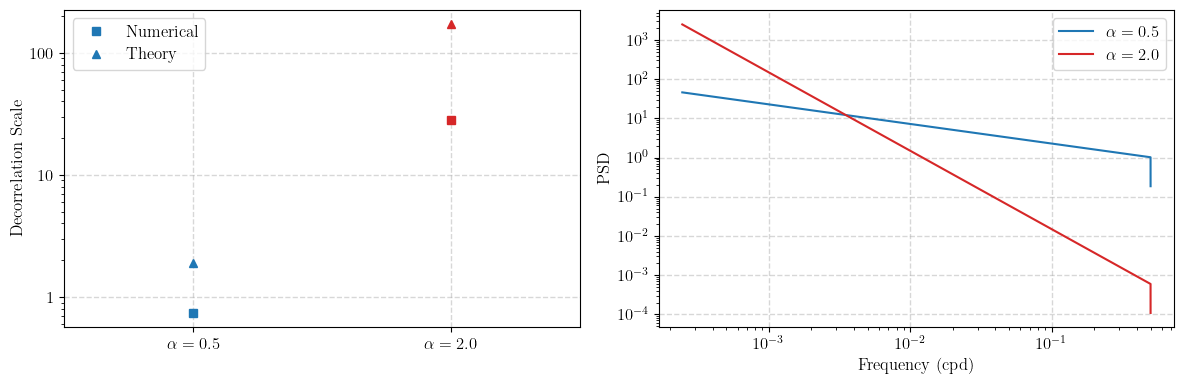

In [8]:
# Create figure
fig,axes = plt.subplots(1,2,figsize=(12,4))
ax1, ax2 = axes.flatten()

#--- Subplot 1 ---# 
ax1.plot([1], [Lt1_days], ls = '', marker = 's', color='tab:blue',label='Numerical')
ax1.plot([1], [Lt1_theory_days], ls = '', marker = '^', color='tab:blue',label='Theory')
ax1.plot([2], [Lt2_days, ], ls = '', marker = 's', color='tab:red')
ax1.plot([2], [Lt2_theory_days], ls = '', marker = '^', color='tab:red')

# Set axis attributes
ax1.set_xticks([1,2])
ax1.set_xlim(0.5,2.5)
ax1.set_yscale('log')
ax1.set_yticks([1,10,100])
ax1.set_yticklabels([1,10,100])
ax1.set_xticklabels([r"$\alpha = " + str(alpha[0]) + "$", r"$\alpha = " + str(alpha[1]) + "$"])
ax1.set_ylabel("Decorrelation Scale")
ax1.grid(ls='--',lw=1.0,alpha=0.5)
ax1.legend(loc='upper left')

#--- Subplot 1 ---# 
ax2.loglog(f1[1:], psd1[1:], color='tab:blue', label=r"$\alpha = " + str(alpha[0]) + "$")
ax2.loglog(f2[1:], psd2[1:], color='tab:red', label=r"$\alpha = " + str(alpha[1]) + "$")

# Set axis attributes
ax2.set_xlabel("Frequency (cpd)")
ax2.set_ylabel("PSD")
ax2.legend()
ax2.grid(ls='--',lw=1.0,alpha=0.5)

# Display figure
plt.tight_layout()
plt.show()

Compute decorrelation scale by integrating over all lags

In [9]:
#--- Time series 1 ---#

# Set the positive and negative lagged autocovariance functions
autocorr_pos = autocorr1
autocorr_neg = np.flip(autocorr1)[:-1]

# Set the positive and negative lag variable
x_ref_pos = time_scale1
x_ref_neg = -1 * np.flip(time_scale1)[:-1]

# Concatinate for two-sided autocorrelation
coef = np.concatenate((autocorr_neg, autocorr_pos))
x    = np.concatenate((x_ref_neg, x_ref_pos))

# Compute decorrelation scale over all lags
Lt1_full = dt * trapezoid(coef, x, dx=dt) 

# Convert to days
Lt1_full_days = Lt1_full * (1/24)

#--- Time series 2 ---#

# Set the positive and negative lagged autocovariance functions
autocorr_pos = autocorr2
autocorr_neg = np.flip(autocorr2)[:-1]

# Set the positive and negative lag variable
x_ref_pos = time_scale2
x_ref_neg = -1 * np.flip(time_scale2)[:-1]

# Concatinate for two-sided autocorrelation
coef = np.concatenate((autocorr_neg, autocorr_pos))
x    = np.concatenate((x_ref_neg, x_ref_pos))

# Compute decorrelation scale over all lags
Lt2_full = dt * trapezoid(coef, x, dx=dt) 

# Convert to days
Lt2_full_days = Lt2_full * (1/24)

print(Lt1_full_days, Lt1_theory_days)
print(Lt2_full_days, Lt2_theory_days)

-2.4721935364032293e-06 1.8856180831641265
-1.8398956414718743e-06 170.66666666666666


Compute the decorrelation scale for a range of spectral slopes

In [10]:
# Set parameters for decorrelation scale calculation
alpha_vec = np.arange(0,5,0.1)

# Initialize arrays
Lt_days = np.zeros((len(alpha_vec)))
Lt_theory_days = np.zeros((len(alpha_vec)))

# Loop through spectral slopes
for i in range(len(alpha_vec)): 

    # Grab the ith alpha value
    ialpha = alpha_vec[i]

    # Compute power law time series and spectrum
    t, x, f, psd = generate_powerlaw_data(N=N, alpha=ialpha, random_state=42,dt=dt)

    # Detrend time series 
    x_dt = detrend(x)

    # Compute autocorrelation function
    autocorr, _, _, _, time_scale, _ = compute_autocorr_optimize(x_dt, t, N, 'biased', 0)

    # Compute the decorrelation scale numerically
    Lt = compute_decor_scale_optimize(autocorr,time_scale,dt,'unbiased',0)

    # Set frequency limits (note, grab f = df NOT f = 0)
    f_min, f_max = f[1], f[-1]

    # Compute the decorrelation scale theoretically 
    if ialpha == 1:
        Lt_theory = f_min / np.log(f_max/f_min)
    else: 
        Lt_theory = (1 - ialpha) * ((f_min**(-ialpha))/(f_max**(1-ialpha) - f_min**(1-ialpha)))

    # Convert to days
    Lt_days[i] = Lt * (1/24)
    Lt_theory_days[i] = Lt_theory * (1/24)

Plot decorrelation scale as a function of spectral slope

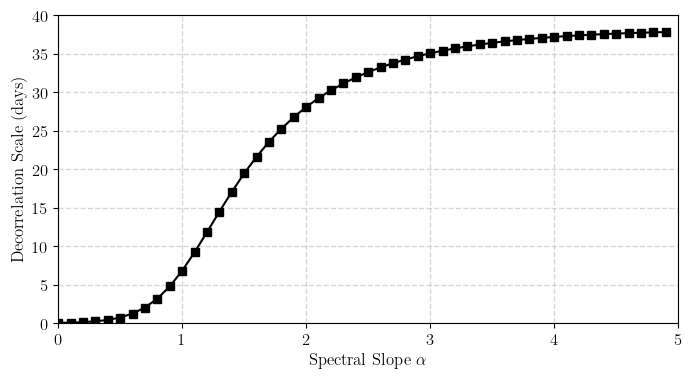

In [11]:
# Compute lowest frequency in the record and convert period to decorrelation scale
T_days = (N*dt)/24
T_decor = T_days/(np.pi)

# Create figure
fig,axes = plt.subplots(figsize=(8,4))

# Plot decorrelation scale as a function of spectral slope (computed numerically)
axes.plot(alpha_vec, Lt_days, ls = '-', marker = 's', color='black',label='Numerical')

# Plot decorrelation scale as a function of spectral slope (computed using theoretical relationship)
#axes.plot(alpha_vec, Lt_theory_days, ls = '--', marker = '^', color='tab:blue',label='Theory')

# Plot the decorrelation scale of the lowest resolved frequency for this record
#axes.axhline(T_decor, ls = '--', lw = 2, color='tab:red')

# Set axis attributes
axes.set_xlim(0,5)
axes.set_ylim(0,40)
axes.set_xlabel(r'Spectral Slope $\alpha$')
axes.set_ylabel(r"Decorrelation Scale (days)")
axes.grid(ls='--',lw=1.0,alpha=0.5)
#axes.legend(loc='upper left')

Compute decorrelation scales for a range of time record lengths 

In [12]:
# Set parameters for decorrelation scale calculation
hours_per_day = 24
days_per_year = 365
hours_per_year = days_per_year * hours_per_day
fractions = np.arange(0.1, 2.01, 0.1)  # from 0.1 to 2.0 years in 0.1 steps
durations_hours = fractions * hours_per_year
N_vec = durations_hours/dt

# Initialize arrays
Lt_days = np.zeros((len(N_vec)))

# Loop through spectral slopes
for i in range(len(N_vec)): 

    # Grab the ith alpha value
    iN = int(N_vec[i])

    # Compute power law time series and spectrum
    t, x, f, psd = generate_powerlaw_data(N=iN, alpha=2.0, random_state=42,dt=dt)

    # Detrend time series 
    x_dt = detrend(x)

    # Compute autocorrelation function
    autocorr, _, _, _, time_scale, _ = compute_autocorr_optimize(x_dt, t, iN, 'biased', 0)

    # Compute the decorrelation scale numerically
    Lt = compute_decor_scale_optimize(autocorr,time_scale,dt,'unbiased',0)

    # Convert to days
    Lt_days[i] = Lt * (1/24)

Plot decorrelation scale as a function of record length

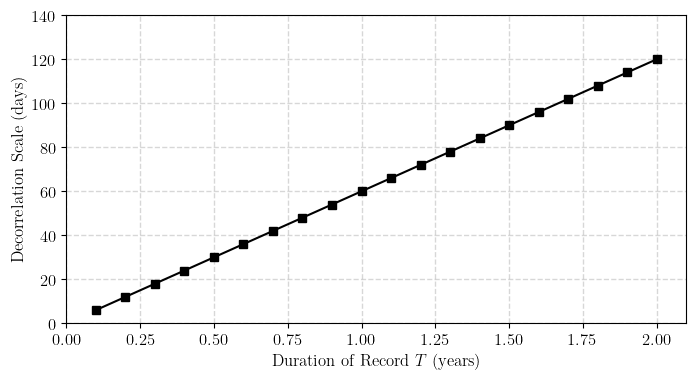

In [13]:
# Compute duration in years
durations_years = durations_hours*(1/24)*(1/365)

# Create figure
fig,axes = plt.subplots(figsize=(8,4))

#--- Subplot 1 ---# 
axes.plot(durations_years, Lt_days, ls = '-', marker = 's', color='black',label='Numerical')

# Set axis attributes
axes.set_xlim(0,2.1)
axes.set_ylim(0,140)
axes.set_xlabel(r'Duration of Record $T$ (years)')
axes.set_ylabel(r"Decorrelation Scale (days)")
axes.grid(ls='--',lw=1.0,alpha=0.5)

Normalize the decorrelation scale by the length of record 

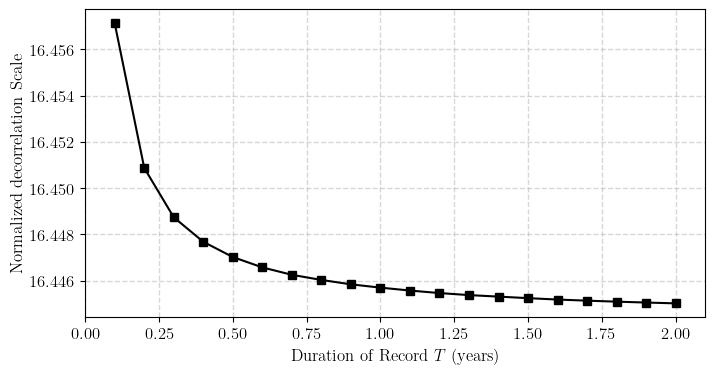

In [14]:
# Compute duration in years
durations_days = durations_hours*(1/24)
durations_years = durations_hours*(1/24)*(1/365)

# Compute the decorrelation scale normalized by the length of record
Lt_norm = (Lt_days/durations_days)*100

# Create figure
fig,axes = plt.subplots(figsize=(8,4))

#--- Subplot 1 ---# 
axes.plot(durations_years, Lt_norm, ls = '-', marker = 's', color='black')

# Set axis attributes
axes.set_xlim(0,2.1)
axes.set_xlabel(r'Duration of Record $T$ (years)')
axes.set_ylabel(r"Normalized decorrelation Scale")
axes.grid(ls='--',lw=1.0,alpha=0.5)

## **Section 2**: Computing uncertainties

Compute uncertainties for the decorrelation estimates using the bootstrap method

In [66]:
# Set parameters for synthetic data
dt = 1          # Time interval (days)
T  = 20*(365)   # Duration of record (days)        
N  = int(T/dt)  # Number of data points in our record

# Generate fake data 
t, x, f, psd = generate_powerlaw_data(N=N, alpha=2.0, random_state=42,dt=dt)

# Make the array a masked array 
mask = np.zeros(x.shape, dtype=bool)  # all False = nothing masked
x_m = np.ma.array(x, mask=mask)

# Set parameters
window_length = int(365)                  # Number of points in a window (1 year)
stride = int(365/2)                       # Number of points for stride length between windows (6 months) 
J      = ((N - window_length)/stride) + 1 # Number of windows 
m      = int(J**(1/2))                    # Number of windows per bootstrap iteration 
B      = 1000                             # Number of bootstrap replicates

# Compute decorrelation scale estimate and uncertainty
mean_tau, std_tau, stdm_tau, CI_tau, tau_boot = bootstrap_decorrelation_scale(x_m, t, window_length, dt, 
                                                                              bias='unbiased', norm=0, stride=stride, 
                                                                              m=m, B=B, lag=None, random_seed=42)

# Print results
print('Decorrelation Scale: ' + str(np.round(mean_tau)) + ' days')
print('Standard Deviation: ' + str(np.round(std_tau)) + ' days')
print('Standard error of the mean: ' + str(np.round(stdm_tau,2)) + ' days')
print('95% confidence interval: ' + str(np.round(CI_tau[0])) + ' to ' + str(np.round(CI_tau[1])) + ' days')

Decorrelation Scale: 46.0 days
Standard Deviation: 6.0 days
Standard error of the mean: 0.18 days
95% confidence interval: 36.0 to 57.0 days


Plot figures to demonstrate analysis

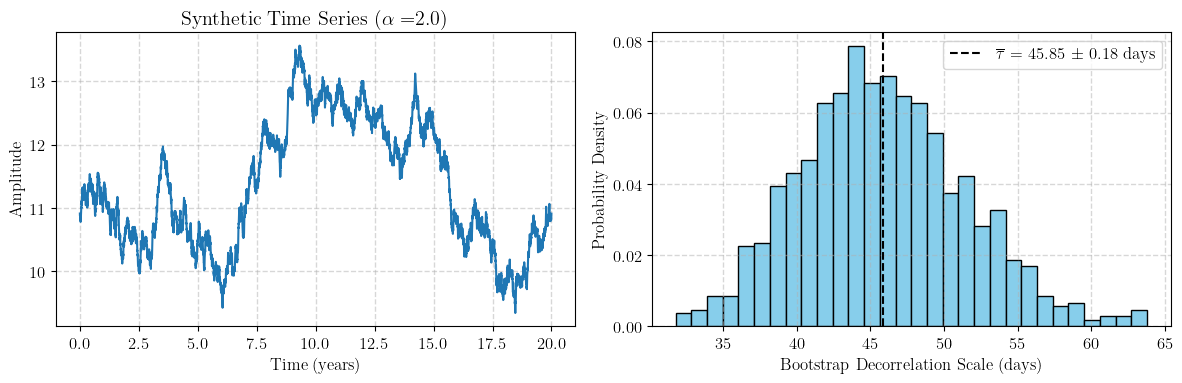

In [67]:
# Create figure
fig,axes = plt.subplots(1,2,figsize=(12,4))
ax1, ax2 = axes.flatten()

#--- Subplot 1 ---# 
ax1.plot(t*(1/365), x, color='tab:blue')

# Set axis attributes
ax1.set_title(r'Synthetic Time Series ($\alpha$ =' + str(alpha[1]) + ')')
ax1.set_xlabel("Time (years)")
ax1.set_ylabel("Amplitude")
ax1.grid(ls='--',lw=1.0,alpha=0.5)

#--- Subplot 2 ---# 
ax2.hist(tau_boot, bins=30, density=True, color="skyblue", edgecolor="k")
ax2.axvline(mean_tau, color='k', ls = '--', label = r'$\overline{\tau}$ = ' + str(np.round(mean_tau,2)) + r' $\pm$ ' + str(np.round(stdm_tau,2)) +' days')

# Set axis attributes
ax2.set_xlabel("Bootstrap Decorrelation Scale (days)")
ax2.set_ylabel("Probability Density")
ax2.grid(ls='--',lw=1.0,alpha=0.5)
ax2.legend()

# Display figure
plt.tight_layout()
plt.show()

Compute the series correlation in the bootstrap samples

In [68]:
# Compute autocorrelation function
autocorr, _, _, _, lag, _ = compute_autocorr_optimize(tau_boot, np.arange(B), B, 'biased', 0)

# Compute the decorrelation scale numerically
tau = compute_decor_scale_optimize(autocorr,lag,1,'unbiased',0)

print(tau)

1.0042143174929696


Compute uncertainty using the perturbation method

In [69]:
# Define absolute time series 
start_time = datetime(2016, 1, 1, 0, 0, 0)
time = np.array([start_time + timedelta(days=int(h)) for h in t])

# Segment the time series 
segments = segment_time_series(time, x, segment_years=1, overlap=0.5)

# Initialize arrays
nseg,ntime = np.shape(segments)[0], np.shape(segments)[2]
autocorr_seg = np.zeros((nseg,ntime))
time_scale_seg = np.zeros((nseg,ntime))

# Loop through segments
for i, (tseg, dseg) in enumerate(segments):

    # Compute the elapsed time from beginning of segmented time series (units: seconds)
    t0 = tseg[0]
    time_elapsed_seg = np.array([(t - t0).total_seconds() for t in tseg])
    
    # Detrend data record 
    data_dt = detrend(dseg)

    # Compute autocorrelation function
    autocorr_seg[i,:], _, _, _, time_scale_seg[i,:], _ = compute_autocorr_optimize(data_dt, time_elapsed_seg, ntime, 'biased', 0)

# Compute the mean autocorrelation function 
meanAutocorr = np.nanmean(autocorr_seg, axis=0)

# Compute the standard deviation and the number of samples 
stdAutocorr = np.nanstd(autocorr_seg, axis=0, ddof=1)
nAutocorr   = np.count_nonzero(~np.isnan(autocorr_seg), axis=0)

# Compute the standard error of the mean (assuming that each data point is an independent observations)
stdmAutocorr   = stdAutocorr/np.sqrt(nAutocorr)

# Compute the decorrelation scale 
tau_seg = compute_decor_scale_optimize(meanAutocorr,time_scale_seg[0,:],dt*24*60*60,'unbiased',0)

# Estimate the decorrelation scale's uncertainty by perturbing the autocorrelation function by 1 standard deviation
tau_ustd = compute_decor_scale_optimize(meanAutocorr + stdmAutocorr ,time_scale_seg[0,:] ,dt*24*60*60,'unbiased',0)
tau_lstd = compute_decor_scale_optimize(meanAutocorr - stdmAutocorr ,time_scale_seg[0,:] ,dt*24*60*60,'unbiased',0)

# Compute the average standard error 
std_upper = tau_ustd - tau_seg
std_lower = abs(tau_lstd - tau_seg)
tau_seg_stdm  = np.mean([std_upper, std_lower])

# Cnvert to units of days
tau_seg_days = tau_seg*(1/60)*(1/60)*(1/24)
tau_seg_stdm_days = tau_seg_stdm*(1/60)*(1/60)*(1/24)

# Print results
print('Decorrelation scale: ' + str(np.round(tau_seg_days,2)) + ' days')
print('Standard error of the mean: ' + str(np.round(tau_seg_stdm_days,2)) + ' days')


Decorrelation scale: 42.99 days
Standard error of the mean: 2.24 days


Plot the perturbed autocorrelation function

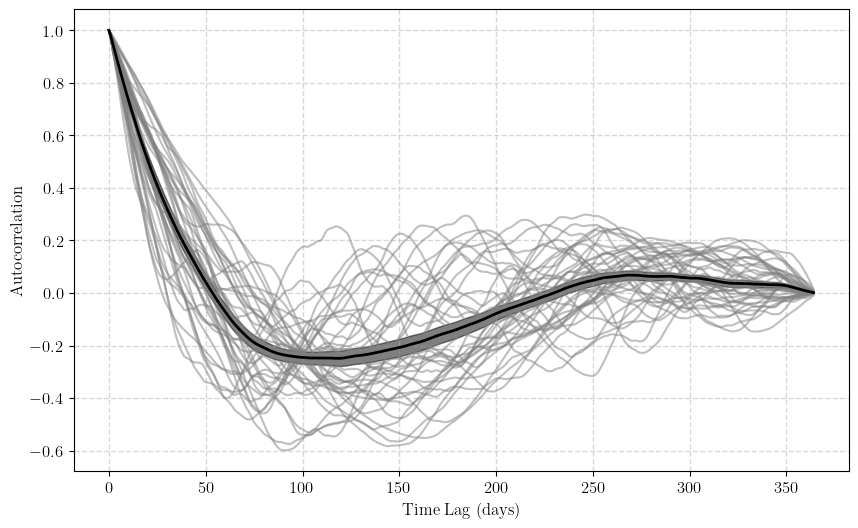

In [70]:
# Convert to days
time_scale_days = time_scale_seg[0,:] * (1/60) * (1/60) * (1/24)

# Create figure
fig,ax = plt.subplots(figsize=(10,6))

# Plot the autocorrelation from each window
ax.plot(time_scale_days,autocorr_seg.T,color='grey',alpha=0.5)

# Plot the mean autocorrelation and its uncertainty
ax.plot(time_scale_days,meanAutocorr,'k-',lw=2)
ax.fill_between(time_scale_days,meanAutocorr + stdmAutocorr, meanAutocorr - stdmAutocorr, alpha=0.5,color='k')

# Set axis attributes
#ax.set_xlim(0,365)
#ax.set_ylim(-0.4,1)
ax.set_xlabel(r'Time Lag (days)')
ax.set_ylabel(r"Autocorrelation")
ax.grid(ls='--',lw=1.0,alpha=0.5)



## **Section 3**: Methods for computing the decorrelation scale

Compute decorrelation scales using the four method outlined

In [3]:
# Set parameters for synthetic data
dt = 1            # Time interval (hours)
T  = 2*(365)*24   # Duration of record (hours)        
N  = int(T/dt)    # Number of data points in our record
alpha = 2.0       # Spectral slope

# Generate fake data 
t, x, f, psd = generate_powerlaw_data(N=N, alpha=alpha, random_state=42, dt=dt)

# Compute autocorrelation function 
autocorr, _, _, _, time_scale, _ = compute_autocorr_optimize(x, t, N, 'biased', 0)

# Compute decorrelation scales
integral_scale = compute_decor_scale_optimize(autocorr,time_scale,dt,'unbiased',0)
scales         = compute_decorrelation_scales(autocorr, time_scale, max_lag_fit=None)

# Print results
print('Integral Scale: ' + str(np.round(integral_scale*(1/24),2)) + ' days')
print('e-Folding Scale: ' + str(np.round(scales['efolding_full']*(1/24),2)) + ' days')
print('Zero-crossing Scale: ' + str(np.round(scales['zero_crossing_full']*(1/24),2)) + ' days')
print('Half-width at half-maximum Scale: ' + str(np.round(scales['fwhm']*(1/24),2)) + ' days')
print('Exponential Fit Scale: ' + str(np.round(scales['exp_fit_full']*(1/24),2)) + ' days')

Integral Scale: 121.38 days
e-Folding Scale: 163.0 days
Zero-crossing Scale: 267.08 days
Half-width at half-maximum Scale: 128.33 days
Exponential Fit Scale: 132.77 days


Plot results

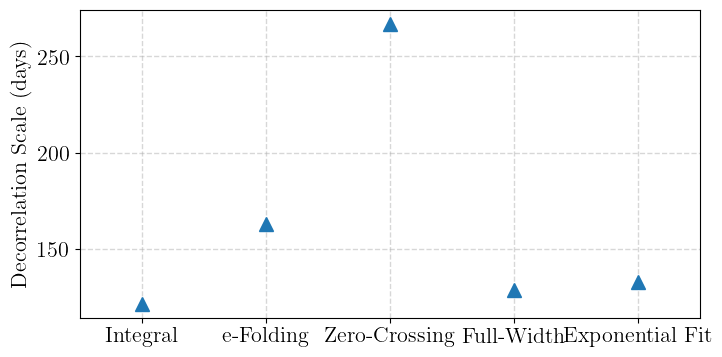

In [4]:
# Create figure
fig,ax = plt.subplots(figsize=(8,4))

#--- Subplot 1 ---# 
ax.plot([1], [integral_scale*(1/24)], ls = '', marker = '^', color='tab:blue', ms=10)
ax.plot([2], [scales['efolding_full']*(1/24)], ls = '', marker = '^', color='tab:blue', ms=10)
ax.plot([3], [scales['zero_crossing_full']*(1/24)], ls = '', marker = '^', color='tab:blue', ms=10)
ax.plot([4], [scales['fwhm']*(1/24)], ls = '', marker = '^', color='tab:blue', ms=10)
ax.plot([5], [scales['exp_fit_full']*(1/24)], ls = '', marker = '^', color='tab:blue', ms=10)

# Set axis attributes
ax.set_xticks([1,2,3,4,5])
ax.set_xlim(0.5,5.5)
ax.set_xticklabels(["Integral", "e-Folding", "Zero-Crossing", "Full-Width", "Exponential Fit"])
ax.set_ylabel("Decorrelation Scale (days)")
ax.grid(ls='--',lw=1.0,alpha=0.5)

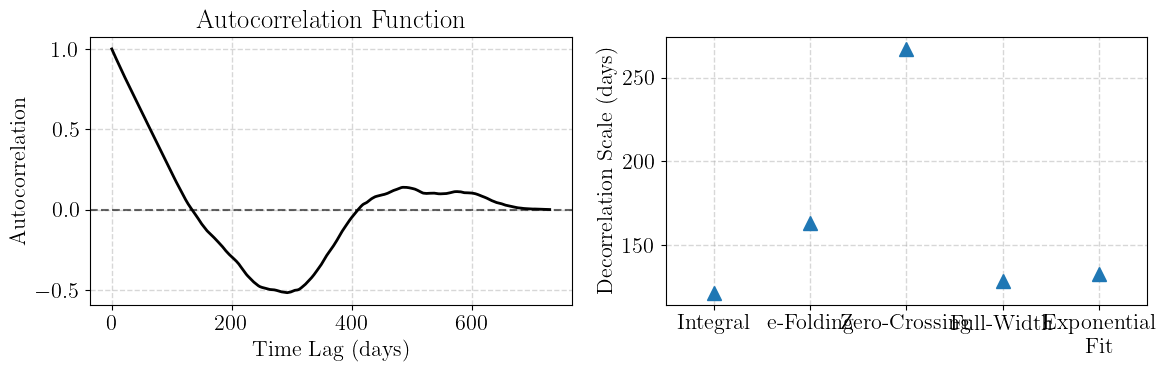

In [5]:
# Create figure
fig,axes = plt.subplots(1,2,figsize=(12,4))
ax1, ax2 = axes.flatten()

#--- Subplot 1 ---# 
ax1.plot(time_scale*(1/24),autocorr,'k-',lw=2)
ax1.axhline(0,color='k',ls='--',alpha=0.6)

# Set axis attributes
ax1.set_title(r'Autocorrelation Function')
ax1.set_xlabel("Time Lag (days)")
ax1.set_ylabel("Autocorrelation")
ax1.grid(ls='--',lw=1.0,alpha=0.5)

#--- Subplot 2 ---# 
ax2.plot([1], [integral_scale*(1/24)], ls = '', marker = '^', color='tab:blue', ms=10)
ax2.plot([2], [scales['efolding_full']*(1/24)], ls = '', marker = '^', color='tab:blue', ms=10)
ax2.plot([3], [scales['zero_crossing_full']*(1/24)], ls = '', marker = '^', color='tab:blue', ms=10)
ax2.plot([4], [scales['fwhm']*(1/24)], ls = '', marker = '^', color='tab:blue', ms=10)
ax2.plot([5], [scales['exp_fit_full']*(1/24)], ls = '', marker = '^', color='tab:blue', ms=10)

# Set axis attributes
ax2.set_xticks([1,2,3,4,5])
ax2.set_xlim(0.5,5.5)
ax2.set_xticklabels(["Integral", "e-Folding", "Zero-Crossing", "Full-Width", "Exponential\nFit"])
ax2.set_ylabel("Decorrelation Scale (days)")
ax2.grid(ls='--',lw=1.0,alpha=0.5)

# Display figure
plt.tight_layout()
plt.show()

Plot the synthetic data and power spectrum 

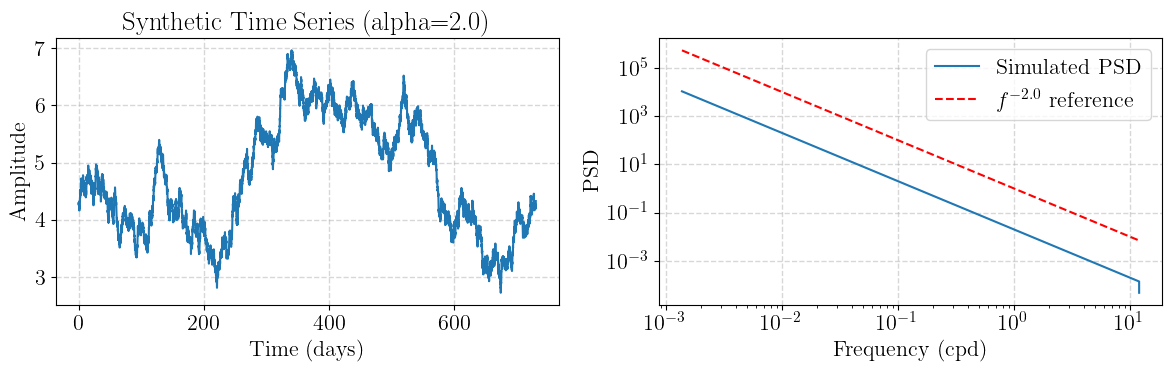

In [6]:
# Convert time to days and frequency to cpd
t_day = t * (1/24)
f_cpd = f * (24)

# Create figure
fig,axes = plt.subplots(1,2,figsize=(12,4))
ax1, ax2 = axes.flatten()

#--- Subplot 1 ---# 
ax1.plot(t_day, x, color='tab:blue')

# Set axis attributes
ax1.set_title('Synthetic Time Series (alpha=' + str(alpha) + ')')
ax1.set_xlabel("Time (days)")
ax1.set_ylabel("Amplitude")
ax1.grid(ls='--',lw=1.0,alpha=0.5)

#--- Subplot 1 ---# 
ax2.loglog(f_cpd[1:], psd[1:], color='tab:blue', label="Simulated PSD")
plt.loglog(f_cpd[1:], f_cpd[1:]**(-alpha), 'r--', label=r"$f^{-" + str(alpha) + r"}$ reference")

# Set axis attributes
ax2.set_xlabel("Frequency (cpd)")
ax2.set_ylabel("PSD")
ax2.legend()
ax2.grid(ls='--',lw=1.0,alpha=0.5)

# Display figure
plt.tight_layout()
plt.show()

Now, let's be a little more rigorous and compute the uncertainty for all these decorrelation scale estimates using the perturbation method 

In [7]:
# Set parameters for synthetic data
dt = 1               # Time interval (hours)
T  = 4*(365)*(24)    # Duration of record (hours)        
N  = int(T/dt)       # Number of data points in our record
alpha = 1.5          # Spectral Slope

# Generate fake data 
t, x, f, psd = generate_powerlaw_data(N=N, alpha=alpha, random_state=42,dt=dt)

# Make the array a masked array 
mask = np.zeros(x.shape, dtype=bool)  # all False = nothing masked
x_m = np.ma.array(x, mask=mask)

# Define absolute time series 
start_time = datetime(2000, 1, 1, 0, 0, 0)
time = np.array([start_time + timedelta(hours=int(h)) for h in t])

# Segment the time series 
segments = segment_time_series(time, x, segment_years=1, overlap=0.5)

# Initialize arrays
nseg,ntime = np.shape(segments)[0], np.shape(segments)[2]
autocorr_seg = np.zeros((nseg,ntime))
time_scale_seg = np.zeros((nseg,ntime))

# Loop through segments
for i, (tseg, dseg) in enumerate(segments):

    # Compute the elapsed time from beginning of segmented time series (units: seconds)
    t0 = tseg[0]
    time_elapsed_seg = np.array([(t - t0).total_seconds() for t in tseg])
    
    # Detrend data record 
    data_dt = detrend(dseg)

    # Compute autocorrelation function
    autocorr_seg[i,:], _, _, _, time_scale_seg[i,:], _ = compute_autocorr_optimize(data_dt, time_elapsed_seg, ntime, 'biased', 0)

# Compute the mean autocorrelation function 
meanAutocorr = np.nanmean(autocorr_seg, axis=0)

# Compute the standard deviation and the number of samples 
stdAutocorr = np.nanstd(autocorr_seg, axis=0, ddof=1)
nAutocorr   = np.count_nonzero(~np.isnan(autocorr_seg), axis=0)

# Compute the standard error of the mean (assuming that each data point is an independent observations)
stdmAutocorr   = stdAutocorr/np.sqrt(nAutocorr)

# Compute the decorrelation scale 
integral_scale = compute_decor_scale_optimize(meanAutocorr,time_scale_seg[0,:],dt*60*60,'unbiased',0)
scales         = compute_decorrelation_scales(meanAutocorr, time_scale_seg[0,:], max_lag_fit=None)

# Estimate the decorrelation scale's uncertainty by perturbing the autocorrelation function by 1 standard deviation
int_ustd    = compute_decor_scale_optimize(meanAutocorr + stdmAutocorr ,time_scale_seg[0,:] ,dt*60*60,'unbiased',0)
int_lstd    = compute_decor_scale_optimize(meanAutocorr - stdmAutocorr ,time_scale_seg[0,:] ,dt*60*60,'unbiased',0)
scales_ustd = compute_decorrelation_scales(meanAutocorr + stdmAutocorr, time_scale_seg[0,:], max_lag_fit=None)
scales_lstd = compute_decorrelation_scales(meanAutocorr - stdmAutocorr, time_scale_seg[0,:], max_lag_fit=None)

# Compute the average standard error 
std_upper = int_ustd - integral_scale
std_lower = abs(int_lstd - integral_scale)
integral_scale_stdm  = np.mean([std_upper, std_lower])

std_upper = {k: scales_ustd[k] - scales[k] for k in scales}
std_lower = {k: abs(scales_lstd[k] - scales[k]) for k in scales}
scales_stdm = {k: np.mean([std_upper[k], std_lower[k]]) for k in scales}

# Convert from units of seconds to units of days
integral_scale_days = integral_scale*(1/60)*(1/60)*(1/24)
integral_scale_stdm_days = integral_scale_stdm*(1/60)*(1/60)*(1/24)

scales_days = {k: v * (1/60) * (1/60) * (1/24) for k, v in scales.items()}
scales_stdm_days = {k: v * (1/60) * (1/60) * (1/24) for k, v in scales_stdm.items()}
f_cpd = f * 24

Plot the synthetic data and power spectrum 

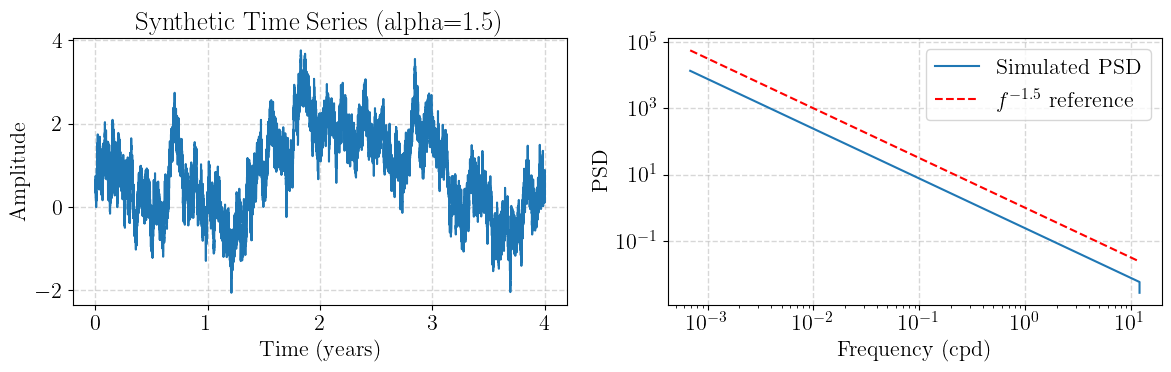

In [8]:
# Convert to units of years
t_year = t * (1/24)*(1/365)

# Create figure
fig,axes = plt.subplots(1,2,figsize=(12,4))
ax1, ax2 = axes.flatten()

#--- Subplot 1 ---# 
ax1.plot(t_year, x, color='tab:blue')

# Set axis attributes
ax1.set_title('Synthetic Time Series (alpha=' + str(alpha) + ')')
ax1.set_xlabel("Time (years)")
ax1.set_ylabel("Amplitude")
ax1.grid(ls='--',lw=1.0,alpha=0.5)

#--- Subplot 1 ---# 
ax2.loglog(f_cpd[1:], psd[1:], color='tab:blue', label="Simulated PSD")
plt.loglog(f_cpd[1:], f_cpd[1:]**(-alpha), 'r--', label=r"$f^{-" + str(alpha) + r"}$ reference")

# Set axis attributes
ax2.set_xlabel("Frequency (cpd)")
ax2.set_ylabel("PSD")
ax2.legend()
ax2.grid(ls='--',lw=1.0,alpha=0.5)

# Display figure
plt.tight_layout()
plt.show()

Plot the autocorrelation function and decorrelation scale estimates with uncertainty 

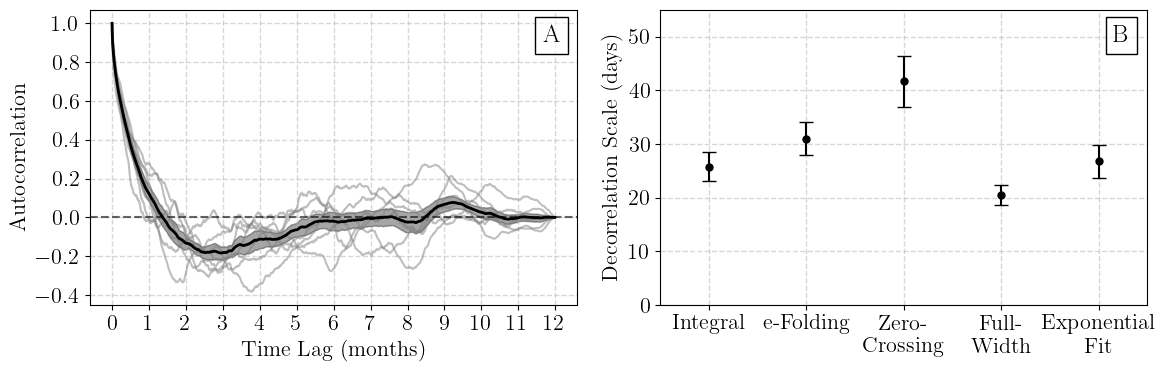

In [19]:
fontsize = 18

# Convert to days
time_scale_days = time_scale_seg[0,:] * (1/60) * (1/60) * (1/24) * (1/30.44)  # in months

# Create figure
fig,axes = plt.subplots(1,2,figsize=(12,4))
ax1, ax2 = axes.flatten()

#--- Subplot 1 ---# 

# Plot the autocorrelation from each window
ax1.plot(time_scale_days,autocorr_seg.T,color='grey',alpha=0.5)

# Plot the mean autocorrelation and its uncertainty
ax1.plot(time_scale_days,meanAutocorr,'k-',lw=2)
ax1.fill_between(time_scale_days,meanAutocorr + stdmAutocorr, meanAutocorr - stdmAutocorr, alpha=0.35,color='k')

# Plot the zero crossing 
ax1.axhline(0,color='k',ls='--',alpha=0.6)

# Set axis attributes
#ax1.set_xlim(0,50)
ax1.set_xlabel("Time Lag (months)")
ax1.set_ylabel("Autocorrelation")
ax1.set_xticks(np.arange(0,13,1))
ax1.set_yticks(np.arange(-0.4,1.2,0.2))
ax1.grid(ls='--',lw=1.0,alpha=0.5)

#--- Subplot 2 ---# 

# Combine all into arrays for looping
x_vals = [1, 2, 3, 4, 5]
y_vals = [
    integral_scale_days,
    scales_days['efolding_full'],
    scales_days['zero_crossing'],
    scales_days['fwhm'],
    scales_days['exp_fit_full']
]
y_errs = [
    integral_scale_stdm_days,
    scales_stdm_days['efolding_full'],
    scales_stdm_days['zero_crossing'],
    scales_stdm_days['fwhm'],
    scales_stdm_days['exp_fit_full']
]

# Plot in a loop
for x, y, e in zip(x_vals, y_vals, y_errs):
    ax2.errorbar(x, y, yerr=e, fmt='o', color='k', ms=5, capsize=5)

# Set axis attributes
ax2.set_xticks([1,2,3,4,5])
ax2.set_xlim(0.5,5.5)
ax2.set_ylim(0,55)
ax2.set_xticklabels(["Integral", "e-Folding", "Zero-\nCrossing", "Full-\nWidth", "Exponential\nFit"])
ax2.set_ylabel("Decorrelation Scale (days)")
ax2.grid(ls='--',lw=1.0,alpha=0.5)

# Label each subplot
pos = [0.93, 0.95]
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, pos, 'B', fontsize = fontsize)

# Display figure
plt.tight_layout()
plt.show()

# Save with high quality
figName = 'figS03.png'
fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)

## **Section 4**: Windowing Analysis

Preform windowing analysis with data sets with various spectral slopes

Progress: 75.0%

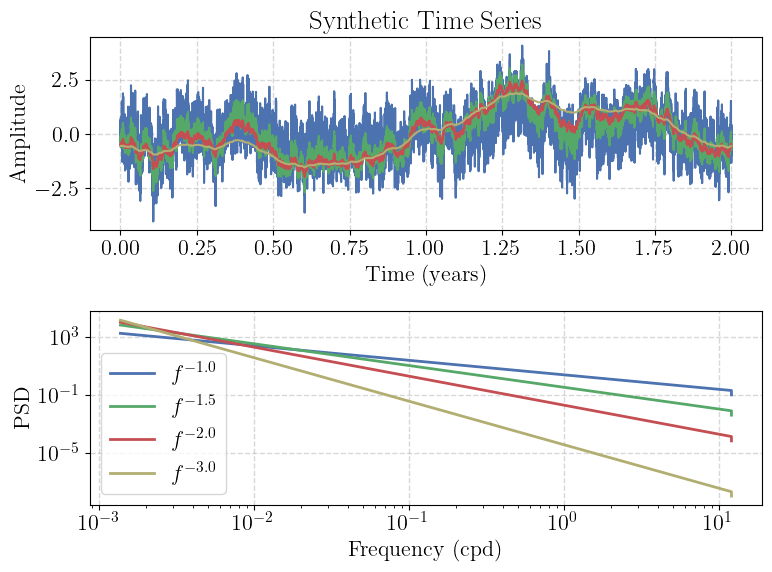

In [3]:
# Set parameters for synthetic data
dt = 1                # Time interval (hours)
T  = 2*(365)*24       # Duration of record (hours)        
N  = int(T/dt)        # Number of data points in our record
alphas_ws = np.array([1, 1.5,2,3]) #np.arange(1.0, 4 + 0.25, 0.25)  # Spectral slopes
n_alpha = len(alphas_ws)
overlap = 0.5 
option_log = True     # True for logarithmic spacing, False for linear spacing
colors = ['#4c72b0', '#55a868', '#c44e52', "#b2ae72"]  # color map for multiple slopes

 # Set parameters for scale analysis
min_window = 100        # ~4 days
max_window = N // 2     # at least 3 windows fit
n_windows  = 20

# Linearly or logarithmic spaced windows rounded to the nearest integer
if option_log == False: 
    wins = np.linspace(min_window, max_window, n_windows)
else: 
    wins = np.logspace(np.log10(min_window), np.log10(max_window), n_windows)
window_sizes = np.round(wins).astype(int)

# Remove duplicates (because rounding may create them)
window_sizes = np.unique(window_sizes)

# Set number of windows
n_windows = len(window_sizes)

# Initialize arrays
Lt_av   = np.zeros((n_alpha, n_windows))
Lt_stdm = np.zeros((n_alpha, n_windows))

# Create figure
fig,axes = plt.subplots(2,1,figsize=(8,6))
ax1,ax2 = axes.flatten()

# Loop through spectral slopes
for i, ialpha in enumerate(alphas_ws):

    # Set progress bar
    progress = (i) / (len(alphas_ws))
    sys.stdout.write(f"\rProgress: {progress:.1%}")
    sys.stdout.flush()

    # Generate simulation data 
    t, x, f, psd = generate_powerlaw_data(N=N, alpha=ialpha, random_state=42, dt=dt)

    # Preform scale analysis
    scales, Lt_mean, Lt_err, _ = windowed_decorrelation_scale(x, t, dt, scales=window_sizes, norm=False, 
                                                                    overlap=overlap, return_windows=True)
    
    # Store results (Lt_mean and Lt_std are 1D arrays of length n_windows)
    Lt_av[i, :]   = Lt_mean
    Lt_stdm[i, :] = Lt_err

    # Convert units of frequency and time 
    f_cpd = f * 24
    t_year = t * (1/24)*(1/365)

    # Plot the ith simulated data record

    #--- Subplot 1 ---# 
    ax1.plot(t_year, x - np.mean(x), color=colors[i])

    #--- Subplot 1 ---# 
    ax2.loglog(f_cpd[1:], psd[1:], lw=2, color=colors[i], label=r"$f^{-" + str(ialpha) + r"}$")

# Set axis attributes
ax1.set_title('Synthetic Time Series')
ax1.set_xlabel("Time (years)")
ax1.set_ylabel("Amplitude")
ax1.grid(ls='--',lw=1.0,alpha=0.5)

# Set axis attributes
ax2.set_xlabel("Frequency (cpd)")
ax2.set_ylabel("PSD")
ax2.legend()
ax2.grid(ls='--',lw=1.0,alpha=0.5)

# Display figure
plt.tight_layout()
plt.show()

# Set zero decorrelation scales to masked data
mask = (Lt_av == 0)
Lt_av   = np.ma.array(Lt_av, mask=mask)
Lt_stdm = np.ma.array(Lt_stdm, mask=mask)

# Convert decorrelation scales to units of days and window size to months
Lt_av_days_ws = Lt_av * (1/24)
Lt_stdm_days_ws = Lt_stdm * (1/24)
window_sizes_months_ws = window_sizes / (24 * 30.44)

Plot Results

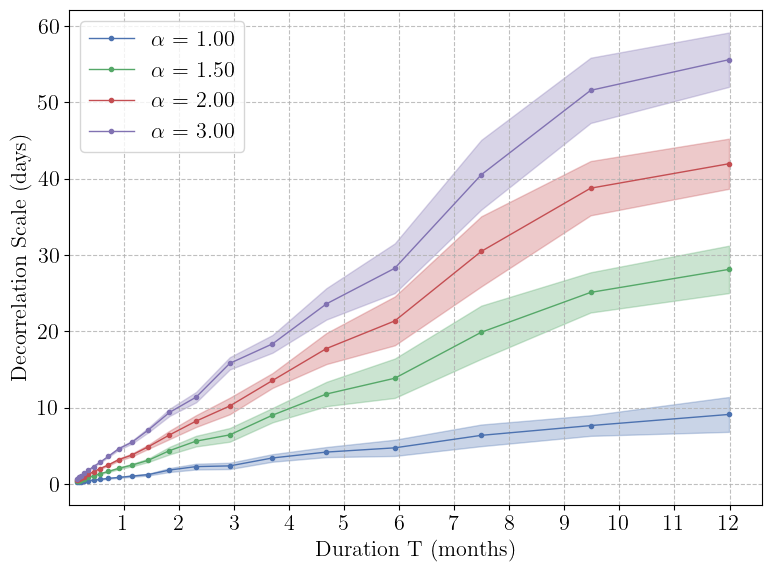

In [4]:
# Set plotting parameters
colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b2']  # color map for multiple slopes

# Set color counter
cn = 0

# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Loop through spectral slopes
for i, alpha in enumerate(alphas_ws):
    
    # Plot just spectral slopes of 1, 1.5, 2, and 3
    if (alpha == 1) | (alpha == 1.5) | (alpha == 2) | (alpha == 3): 

        # Plot mean decorrelation scale
        ax.plot(window_sizes_months_ws, Lt_av_days_ws[i, :], '.-', color=colors[cn],
                linewidth=1, label=r'$\alpha$ = {:.2f}'.format(alpha))
        
        # Plot standard error as shaded region
        ax.fill_between(window_sizes_months_ws,
                        Lt_av_days_ws[i, :] - Lt_stdm_days_ws[i, :],
                        Lt_av_days_ws[i, :] + Lt_stdm_days_ws[i, :],
                        color=colors[cn], alpha=0.3)

        # Reset counter 
        cn += 1

# Set figure attributes
ax.set_xlabel('Duration T (months)')
ax.set_ylabel(r'Decorrelation Scale (days)')
ax.set_xlim(0, np.max(window_sizes_months_ws) * 1.05)
ax.set_xticks(np.arange(1,13))
ax.grid(True,linestyle='--',alpha=0.8)
ax.legend(loc='upper left', fontsize=fontsize)

# Display figure
plt.tight_layout()
plt.show()

Compute the decorrelation scale as a function of spectral slope for difference window sizes

In [5]:
# Set parameters for synthetic data
dt = 1                # Time interval (hours)
T  = 2*(365)*24       # Duration of record (hours)        
N  = int(T/dt)        # Number of data points in our record
alphas_as = np.arange(0,5 + 0.1,0.1)  # Spectral slopes
n_alpha = len(alphas_as)
overlap = 0.5 

# Set window sizes
window_sizes = np.int64(np.array([3, 6, 9, 12]) * 30.44* 24)  # Units: Hours (or number of data points in the record)

# Set number of windows
n_windows = len(window_sizes)

# Initialize arrays
Lt_av   = np.zeros((n_alpha, n_windows))
Lt_stdm = np.zeros((n_alpha, n_windows))

# Loop through spectral slopes
for i, ialpha in enumerate(alphas_as):

    # Set progress bar
    progress = (i) / (len(alphas_as))
    sys.stdout.write(f"\rProgress: {progress:.1%}")
    sys.stdout.flush()

    # Generate fake data 
    t, x, f, psd = generate_powerlaw_data(N=N, alpha=ialpha, random_state=42, dt=dt)

    # Preform scale analysis
    scales, Lt_mean, Lt_err, _ = windowed_decorrelation_scale(x, t, dt, scales=window_sizes, norm=False, 
                                                                    overlap=overlap, return_windows=True)
    
    # Store results (Lt_mean and Lt_std are 1D arrays of length n_windows)
    Lt_av[i, :]   = Lt_mean
    Lt_stdm[i, :] = Lt_err

# Set zero decorrelation scales to masked data
mask = (Lt_av == 0)
Lt_av   = np.ma.array(Lt_av, mask=mask)
Lt_stdm = np.ma.array(Lt_stdm, mask=mask)

# Convert decorrelation scales to units of days and window size to months
Lt_av_days_as = Lt_av * (1/24)
Lt_stdm_days_as = Lt_stdm * (1/24)
window_sizes_months_as = window_sizes / (24 * 30.44)

Progress: 98.0%

Plot the results

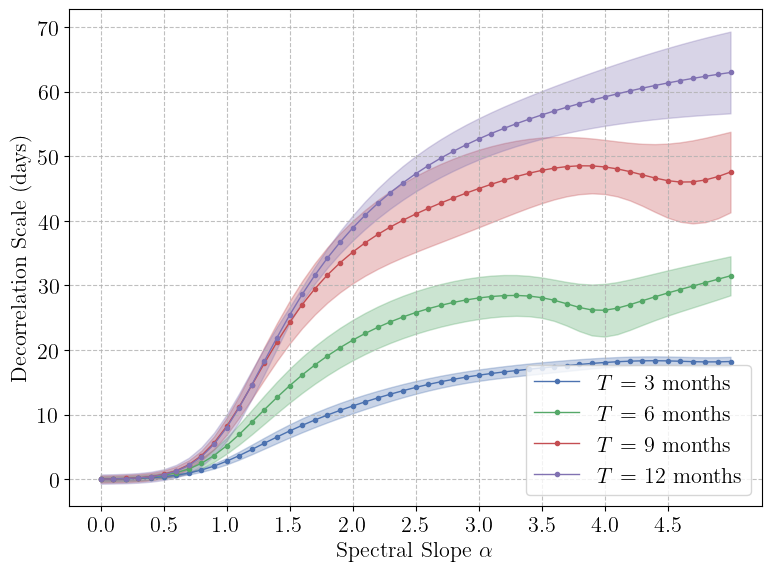

In [6]:
# Set plotting parameters
colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b2'] 

# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Loop through window sizes
for i, window in enumerate(window_sizes_months_as):

    # Plot mean decorrelation scale
    ax.plot(alphas_as, Lt_av_days_as[:,i], '.-', color=colors[i],
            linewidth=1, label=r'$T$ = {:.0f} months'.format(window))
    
    # Plot standard error as shaded region
    ax.fill_between(alphas_as,
                     Lt_av_days_as[:,i] - Lt_stdm_days_as[:,i],
                     Lt_av_days_as[:,i] + Lt_stdm_days_as[:,i],
                     color=colors[i], alpha=0.3)

# Set figure attributes
ax.set_xlabel(r'Spectral Slope $\alpha$')
ax.set_ylabel(r'Decorrelation Scale (days)')
ax.set_xticks(np.arange(0,5,0.5))
ax.grid(True,linestyle='--',alpha=0.8)
ax.legend(loc='lower right', fontsize=fontsize)

# Display figure
plt.tight_layout()
plt.show()

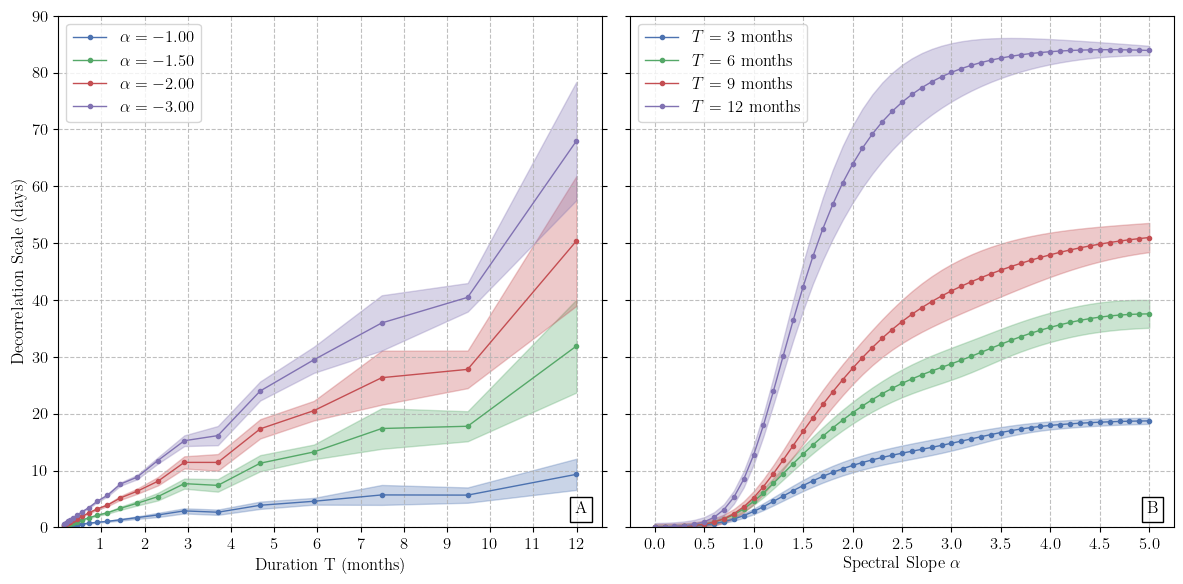

In [ ]:
# Set plotting parameters
colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b2']  # color map for multiple slopes

# Set color counter
cn = 0

# Create the figure
fig, axes = plt.subplots(1,2, figsize=(12, 6))
ax1,ax2 = axes.flatten()

#--- Subplot 2 ---# 

# Loop through spectral slopes
for i, alpha in enumerate(alphas_ws):
    
    # Plot just spectral slopes of 1, 1.5, 2, and 3
    if (alpha == 1) | (alpha == 1.5) | (alpha == 2) | (alpha == 3) | (alpha == 3): 

        # Plot mean decorrelation scale
        ax1.plot(window_sizes_months_ws, Lt_av_days_ws[i, :], '.-', color=colors[cn],
                linewidth=1, label=r'$\alpha = -${:.2f}'.format(alpha))
        
        # Plot standard error as shaded region
        ax1.fill_between(window_sizes_months_ws,
                        Lt_av_days_ws[i, :] - Lt_stdm_days_ws[i, :],
                        Lt_av_days_ws[i, :] + Lt_stdm_days_ws[i, :],
                        color=colors[cn], alpha=0.3)

        # Reset counter 
        cn += 1

# Set figure attributes
ax1.set_xlabel('Duration T (months)')
ax1.set_ylabel(r'Decorrelation Scale (days)')
ax1.set_xlim(0, np.max(window_sizes_months_ws) * 1.05)
ax1.set_xticks(np.arange(1,13))
ax1.set_yticks(np.arange(0,90 + 10,10))
ax1.set_ylim(0,90)
ax1.grid(True,linestyle='--',alpha=0.8)
ax1.tick_params(top=False, bottom=True, left=True, right=True,
            direction='out', length=3.5)
ax1.legend(loc='upper left', fontsize=fontsize)

#--- Subplot 2 ---# 

# Loop through window sizes
for i, window in enumerate(window_sizes_months_as):

    # Plot mean decorrelation scale
    ax2.plot(alphas_as, Lt_av_days_as[:,i], '.-', color=colors[i],
            linewidth=1, label=r'$T$ = {:.0f} months'.format(window))
    
    # Plot standard error as shaded region
    ax2.fill_between(alphas_as,
                     Lt_av_days_as[:,i] - Lt_stdm_days_as[:,i],
                     Lt_av_days_as[:,i] + Lt_stdm_days_as[:,i],
                     color=colors[i], alpha=0.3)

# Set figure attributes
ax2.set_xlabel(r'Spectral Slope $\alpha$')
ax2.set_xticks(np.arange(0,5+0.5,0.5))
ax2.set_yticks(np.arange(0,90 + 10,10))
ax2.set_yticklabels([])
ax2.set_ylim(0,90)
ax2.grid(True,linestyle='--',alpha=0.8)
ax2.tick_params(top=False, bottom=True, left=True, right=False,
            direction='out', length=3.5)
ax2.legend(loc='upper left', fontsize=fontsize)

# Label each subplot
pos = [0.95, 0.05]
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, pos, 'B', fontsize = fontsize)

# Display figure
plt.tight_layout()
plt.show()

# Save with high quality
figName = 'figS04.png'
fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)

Fit a linear trend to each of the lines 

In [78]:
# Initialize arrays
dfit = np.zeros((n_alpha, n_windows))

# Loop through spectral slopes 
for i in range(0,n_alpha):
    
    # Preform linear fit
    dfit[i,:], *_ = unweighted_lsf(Lt_av_days_ws[i, :], window_sizes_months_ws, parameters=0, freqs=None, sigma=None)

Replot with linear fits

In [85]:
colors = cmo.deep_r(len(alphas_ws))
print(colors)

(np.float64(0.18990317894177675), np.float64(0.14087380400423677), np.float64(0.24439758121380578), np.float64(1.0))


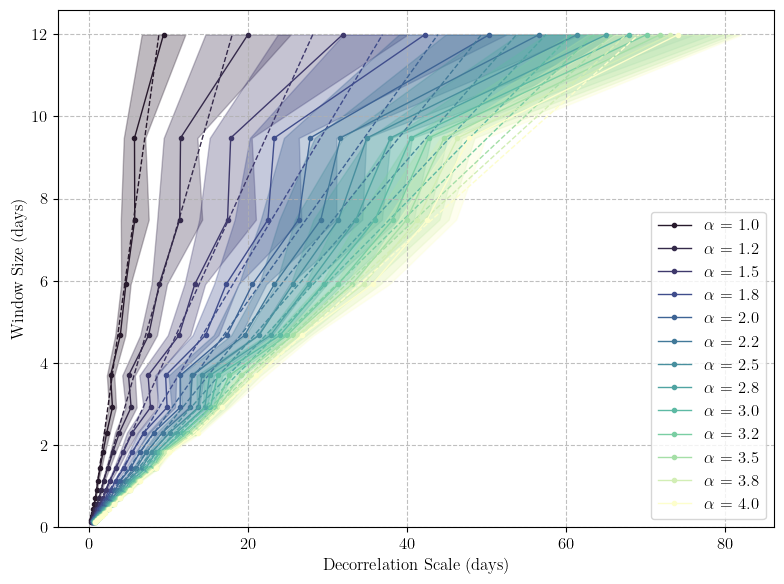

In [87]:
# Set parameters
colors = cmo.deep_r(np.linspace(0, 1, len(alphas_ws)))

# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Loop through spectral slopes
for i, alpha in enumerate(alphas_ws):

    # Plot mean decorrelation scale
    ax.plot(Lt_av_days_ws[i, :], window_sizes_months_ws, '.-', color=colors[i],
            linewidth=1, label=r'$\alpha$ = {:.1f}'.format(alpha))
    
    # Plot the linear fit to the decorrelation scale vs. window size relation
    ax.plot(dfit[i, :], window_sizes_months_ws, '--', color=colors[i],
            linewidth=1)
    
    # Plot standard error as shaded region
    ax.fill_betweenx(window_sizes_months_ws,
                     Lt_av_days_ws[i, :] - Lt_stdm_days_ws[i, :],
                     Lt_av_days_ws[i, :] + Lt_stdm_days_ws[i, :],
                     color=colors[i], alpha=0.3)

# Set figure attributes
ax.set_xlabel(r'Decorrelation Scale (days)')
ax.set_ylabel('Window Size (days)')

ax.set_ylim(0, np.max(window_sizes_months_ws) * 1.05)
ax.grid(True,linestyle='--',alpha=0.8)
ax.legend(loc='lower right', fontsize=fontsize)

# Display figure
plt.tight_layout()
plt.show()

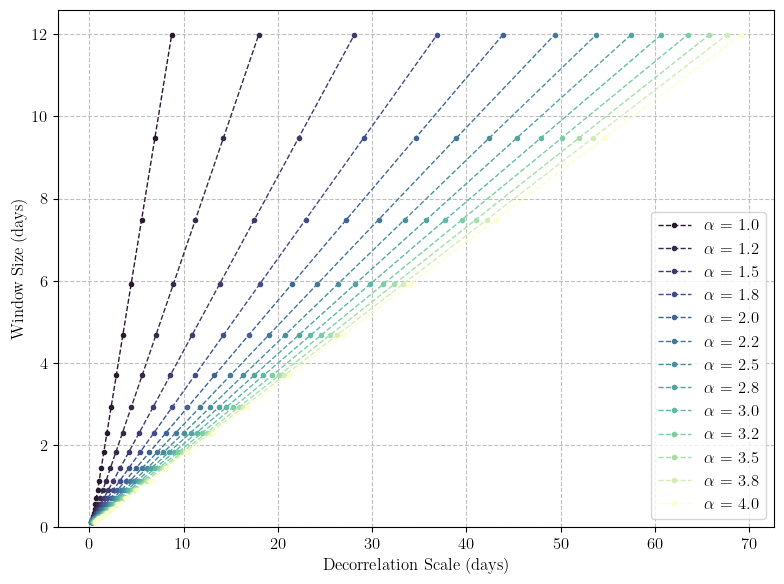

In [89]:
# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

# Loop through spectral slopes
for i, alpha in enumerate(alphas_ws):
    
    # Plot the linear fit to the decorrelation scale vs. window size relation
    ax.plot(dfit[i, :], window_sizes_months_ws, '.--', color=colors[i],
            linewidth=1, label=r'$\alpha$ = {:.1f}'.format(alpha))

# Set figure attributes
ax.set_xlabel(r'Decorrelation Scale (days)')
ax.set_ylabel('Window Size (days)')

ax.set_ylim(0, np.max(window_sizes_months_ws) * 1.05)
ax.grid(True,linestyle='--',alpha=0.8)
ax.legend(loc='lower right', fontsize=fontsize)

# Display figure
plt.tight_layout()
plt.show()

Save data from linear fit into a npz file

In [90]:
# Set the path to direction for saving data 
PATH = ROOT + 'AirSeaCoupling/data/synthetic/'

# Set file path and name
file_path = PATH + "decorrelation_window_size_fit.npz"

# Remove file if file already exists
if os.path.exists(file_path):
    os.remove(file_path)

# Set metadata
metadata = {
    'description': 'Temporal decorrelation scale analysis for synthetic data with prescribed spectral slope',
    'source': 'Synthetic data (2 years of hourly data)',
    'coordinates units': '1 hr'
}

# Save data arrays and metadata to a .npz file
np.savez(file_path, 
        Lt_av          = Lt_av_days_ws,           # Units: days
        Lt_stdm        = Lt_stdm_days_ws,         # Units: days
        Lt_fit         = dfit,                    # Units: days         
        scales         = window_sizes_months_ws,  # Units: months
        alpha          = alphas_ws,
        metadata       = metadata
        )